# Training Statistics Visualization

This notebook visualizes the training progress of the RL agent using data from `training_stats_CNN.json`.

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as pd_plt
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style for aesthetics
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12

In [4]:
# Configuration
STATS_FILE = 'training_stats_CNN.json'
WINDOW_SIZE = 100  # Rolling average window

In [5]:
# Load Data
if os.path.exists(STATS_FILE):
    with open(STATS_FILE, 'r') as f:
        data = json.load(f)
    
    df = pd.DataFrame(data)
    print(f"Loaded {len(df)} episodes.")
    display(df.tail())
else:
    print(f"File {STATS_FILE} not found!")

Loaded 4365 episodes.


,episode,reward,visited_ratio
4360,4361,5.19,1.000000
4361,4362,11.49,1.000000
4362,4363,11.70,1.000000
4363,4364,9.66,1.000000
4364,4365,-22.80,0.944444


In [6]:
# Calculate Rolling Averages
if not df.empty:
    df['reward_ma'] = df['reward'].rolling(window=WINDOW_SIZE, min_periods=1).mean()
    df['visited_ratio_ma'] = df['visited_ratio'].rolling(window=WINDOW_SIZE, min_periods=1).mean()

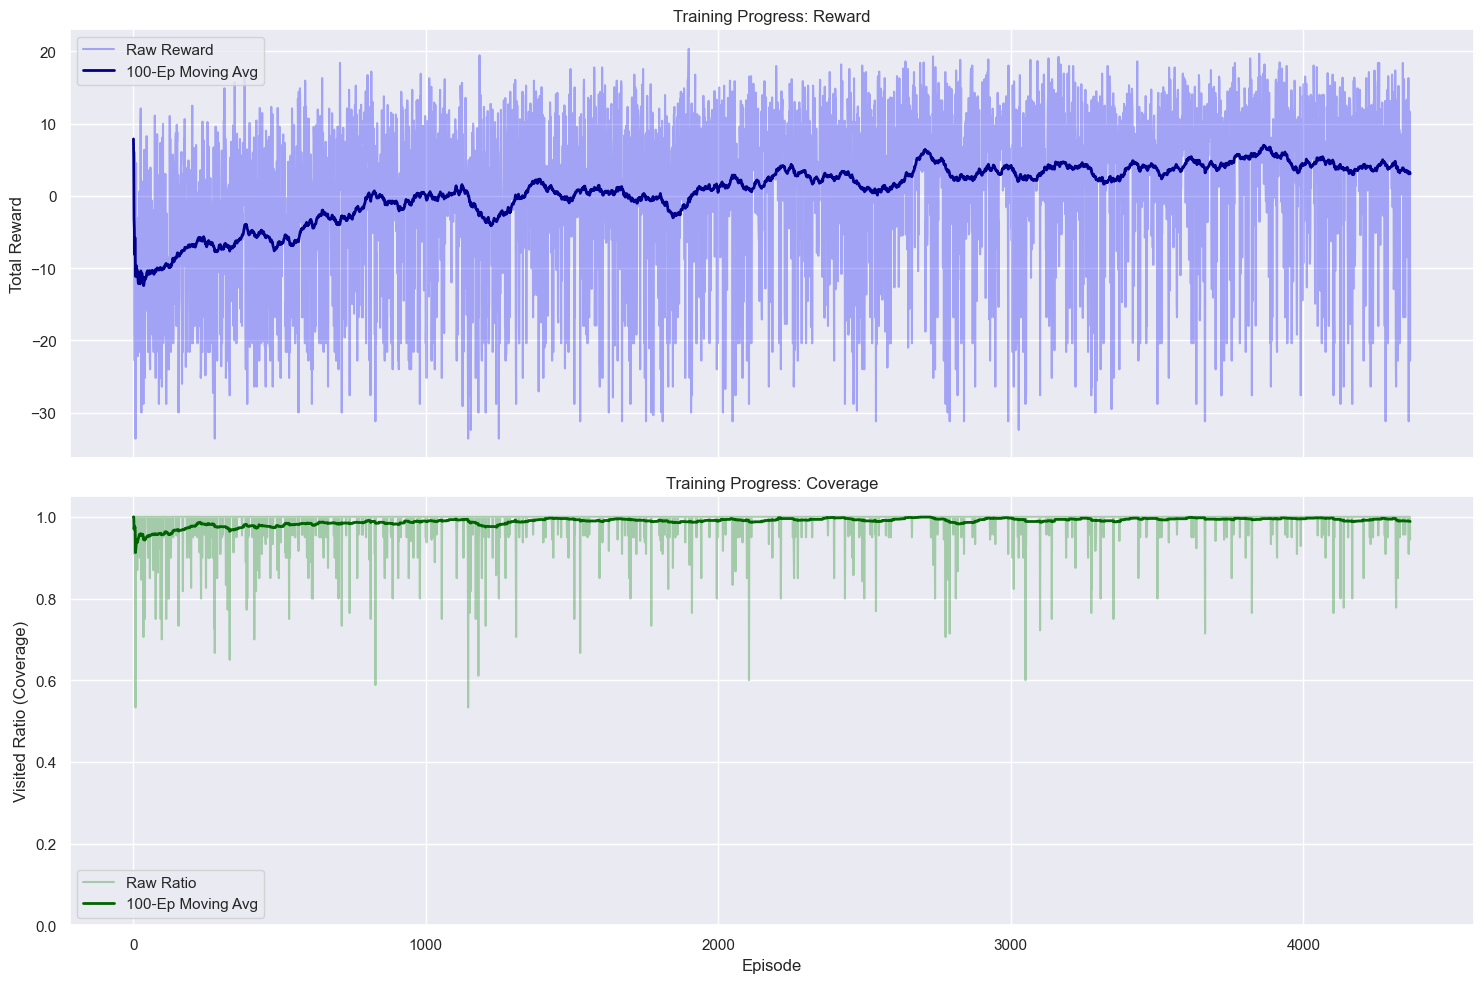

In [7]:
# Plotting
if not df.empty:
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

    # Plot 1: Value / Reward
    sns.lineplot(data=df, x='episode', y='reward', ax=ax1, alpha=0.3, color='blue', label='Raw Reward')
    sns.lineplot(data=df, x='episode', y='reward_ma', ax=ax1, color='darkblue', linewidth=2, label=f'{WINDOW_SIZE}-Ep Moving Avg')
    ax1.set_ylabel('Total Reward')
    ax1.set_title('Training Progress: Reward')
    ax1.legend()

    # Plot 2: Visited Ratio
    sns.lineplot(data=df, x='episode', y='visited_ratio', ax=ax2, alpha=0.3, color='green', label='Raw Ratio')
    sns.lineplot(data=df, x='episode', y='visited_ratio_ma', ax=ax2, color='darkgreen', linewidth=2, label=f'{WINDOW_SIZE}-Ep Moving Avg')
    ax2.set_ylabel('Visited Ratio (Coverage)')
    ax2.set_xlabel('Episode')
    ax2.set_title('Training Progress: Coverage')
    ax2.set_ylim(0, 1.05)
    ax2.legend()

    plt.tight_layout()
    plt.show()